In [44]:
%matplotlib inline

import cv2
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import image as image

In [45]:
def show(I):
    cv2.imshow("image", I)
    key = cv2.waitKey(0)
    cv2.destroyAllWindows()
    cv2.waitKey(1)

icon = cv2.imread("img/icon.jpg")
sample = cv2.imread("img/i-squarelarge.png")

icon = cv2.resize(icon, None, fx=0.5, fy=0.5)
sample = cv2.resize(sample, None, fx=0.5, fy=0.5)

In [46]:
result = cv2.matchTemplate(sample, icon, cv2.TM_CCOEFF_NORMED)

min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

print("Match:", max_val)
print("Location:", max_loc)

h, w = icon.shape[:2]

top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

cv2.rectangle(sample, top_left, bottom_right, (0, 0, 255), 3)

show(sample)

Match: 0.8505834341049194
Location: (511, 149)


In [47]:
#contours test
i_con = cv2.imread("img/i-squarelarge.png")
g = cv2.cvtColor(i_con, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(g, 127, 255, cv2.THRESH_BINARY)

contours,_ = cv2.findContours(binary,
mode=cv2.RETR_EXTERNAL,
method=cv2.CHAIN_APPROX_NONE)

ctrs = cv2.drawContours(i_con, contours, contourIdx=-1,
color=(0,0,255), thickness=3)

show(ctrs)

(160, 125, 3)
0 236
Query keypoints: 104
Train keypoints: 500
Matches: 104
[173.74118041992188, 245.50152587890625, 256.8715515136719, 258.6580810546875, 261.1742858886719]


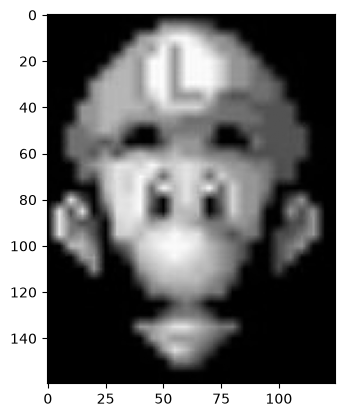

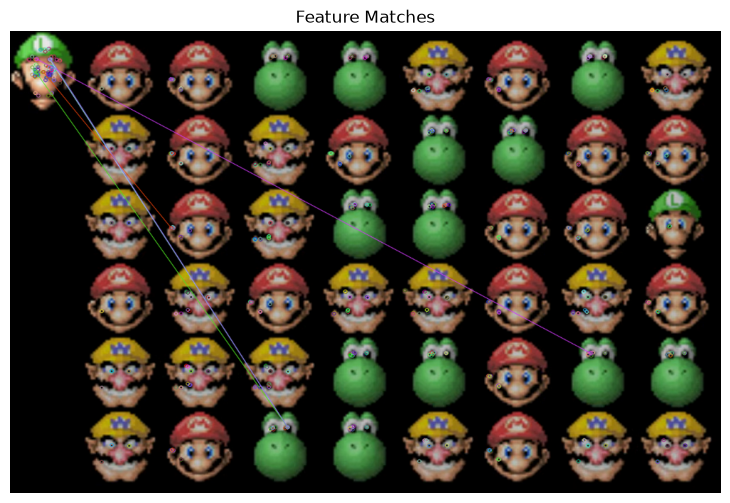

In [49]:
# ORB test
icon = cv2.imread("img/icon.jpg")
sample = cv2.imread("img/i-squarelarge.png")

icon_bw = cv2.cvtColor(icon, cv2.COLOR_BGR2GRAY)
sample_bw = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create()

queryKeypoints, queryDescriptors = orb.detectAndCompute(icon_bw, None)
trainKeypoints, trainDescriptors = orb.detectAndCompute(sample_bw, None)

matcher = cv2.BFMatcher()
matches = matcher.match(queryDescriptors, trainDescriptors)
matches = sorted(matches, key=lambda x: x.distance)

best_matches = matches[:5]

final_img = cv2.drawMatches(
    icon, queryKeypoints,
    sample, trainKeypoints,
    best_matches,
    None
)


final_img = cv2.resize(final_img, (1000, 650))

print(icon.shape)
print(icon_bw.min(), icon_bw.max())
print("Query keypoints:", len(queryKeypoints))
print("Train keypoints:", len(trainKeypoints))
print("Matches:", len(matches))

print([m.distance for m in matches[:5]])
plt.imshow(icon_bw, cmap='gray')
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("Feature Matches")
plt.axis('off')
plt.show()